# Business Case 1: Segmenting Bank Clients

**Goal**: Segment bank customers using Unsupervised Machine Learning techniques.

We use:
- **Gower Distance** — designed for mixed categorical + numerical data
- **K-Medoids** — clustering algorithm robust to categorical data (unlike K-Means)
- **t-SNE** — dimensionality reduction for visualization
- **PCA** — additional dimensionality reduction and cluster profiling

In [132]:
# ── Imports ──────────────────────────────────────────────────────────────────

# For the first time, you may need to install the following libraries:
# %pip install plotly
# %pip install plotly nbformat

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from kmedoids import KMedoids
from sklearn.metrics import silhouette_score

import gower

import plotly.graph_objects as go
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 1. Load & Inspect the Data

In [133]:
# ── Load data ─────────────────────────────────────────────────────────────────
# BUG FIX: use read_excel (not read_csv) and correct extension
df = pd.read_excel('Dataset1_BankClients.xlsx')
metadata=pd.read_excel('BankClients_Metadata.xlsx')


# Drop ID — not informative for clustering
df = df.drop(columns=['ID'])

print(f'Dataset shape: {df.shape}  ({df.shape[0]} clients, {df.shape[1]} features)')
print(f'\nMissing values:\n{df.isnull().sum()}')

Dataset shape: (5000, 17)  (5000 clients, 17 features)

Missing values:
Age            0
Gender         0
Job            0
Area           0
CitySize       0
FamilySize     0
Income         0
Wealth         0
Debt           0
FinEdu         0
ESG            0
Digital        0
BankFriend     0
LifeStyle      0
Luxury         0
Saving         0
Investments    0
dtype: int64


In [134]:
# ── First 5 rows ──────────────────────────────────────────────────────────────
print('--- Prime 5 righe del dataset ---')
display(df.head())

print('\n--- Statistiche Descrittive (Media, Min, Max) ---')
display(df.describe().round(2))

--- Prime 5 righe del dataset ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2



--- Statistiche Descrittive (Media, Min, Max) ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,60.45,0.53,2.46,1.38,1.93,2.49,0.58,0.58,0.43,0.51,0.59,0.53,0.62,0.46,0.47,0.52,2.18
std,21.82,0.50,1.25,0.68,0.76,1.41,0.21,0.21,0.22,0.19,0.17,0.21,0.16,0.22,0.24,0.19,0.82
min,19.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.04,0.00,0.12,0.00,0.00,0.00,1.00
25%,42.00,0.00,2.00,1.00,1.00,1.00,0.41,0.42,0.26,0.37,0.47,0.37,0.51,0.28,0.27,0.40,1.00
50%,61.00,1.00,2.00,1.00,2.00,2.00,0.58,0.59,0.45,0.50,0.60,0.52,0.63,0.45,0.46,0.54,2.00
75%,80.00,1.00,2.00,2.00,3.00,3.00,0.75,0.75,0.60,0.65,0.71,0.70,0.75,0.64,0.66,0.66,3.00
max,95.00,1.00,5.00,3.00,3.00,6.00,0.98,1.00,0.98,0.96,0.99,0.97,0.97,0.99,1.00,0.97,3.00


## 2. Exploratory Data Analysis (EDA)

### 2.1 Demographic Profile: Age and Gender Distribution

We analyze the demographic composition of our sample by examining the age distribution split by gender.

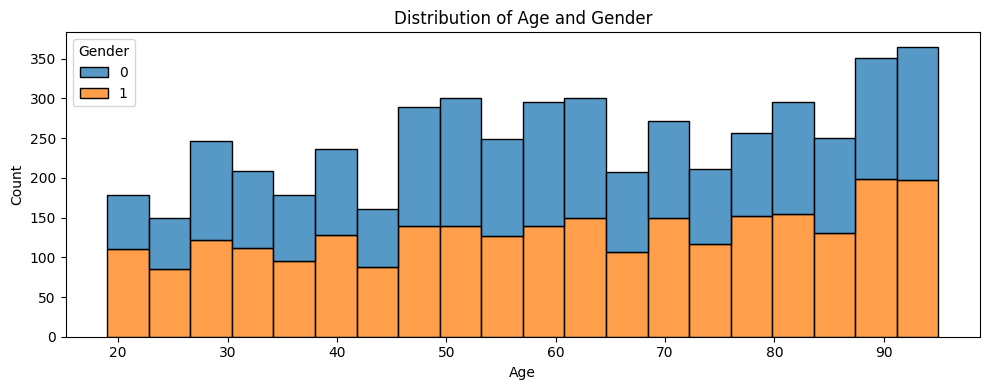

In [135]:
# ── Age & Gender distribution ─────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', bins=20)
plt.title('Distribution of Age and Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2.2 Distribution of Investment Types

We examine how different investment types are distributed across the sample.

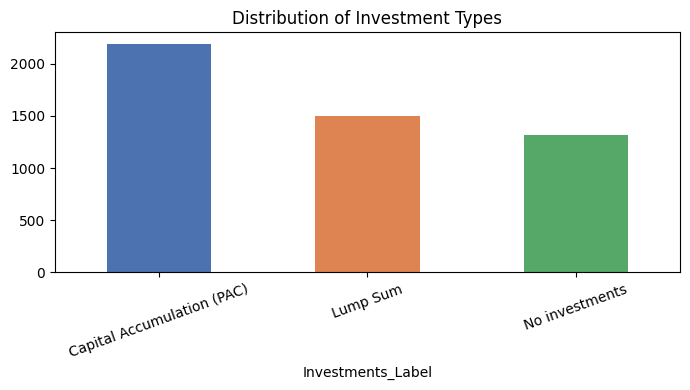

In [136]:
# ── Investment type distribution ──────────────────────────────────────────────
inv_labels = {1: 'No investments', 2: 'Lump Sum', 3: 'Capital Accumulation (PAC)'}
df['Investments_Label'] = df['Investments'].map(inv_labels)

plt.figure(figsize=(7, 4))
df['Investments_Label'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Distribution of Investment Types')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Remove helper column
df = df.drop(columns=['Investments_Label'])

### 2.3 Geographic Patterns: Area vs Financial Variables

We investigate whether the geographic area (Nord, Centro, Sud/Isole) is associated with differences in wealth, income, job composition, and debt levels. This is relevant because Italian macro-regions have well-known socio-economic disparities.

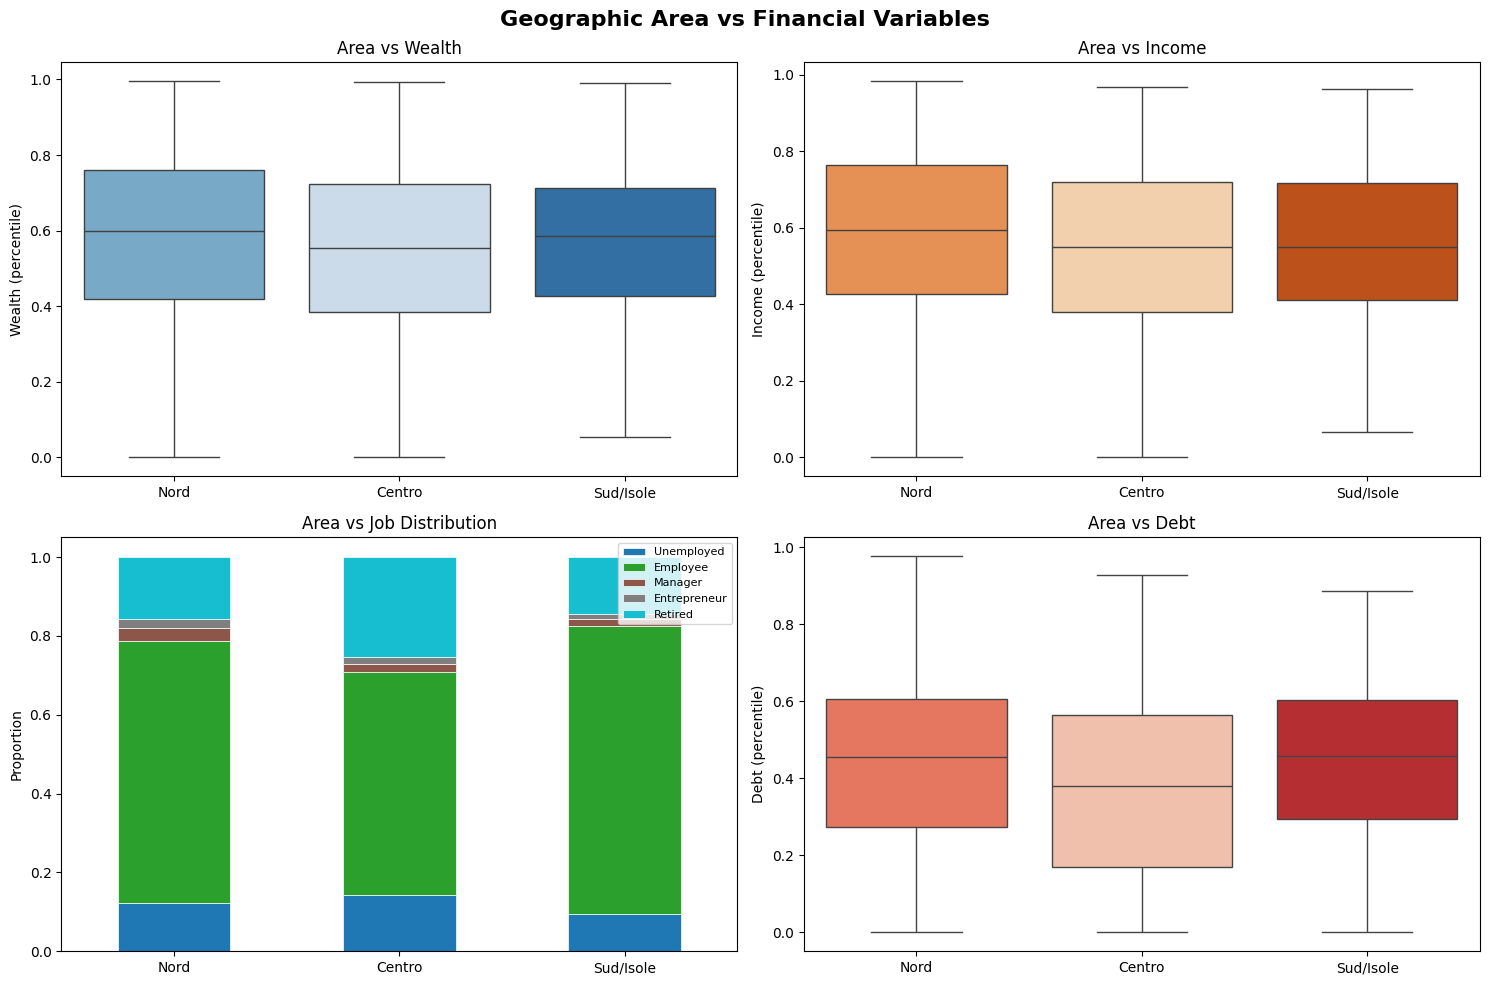

--- Median values by Area ---
           Income  Wealth   Debt
Area_L                          
Nord        0.594   0.599  0.456
Centro      0.551   0.553  0.381
Sud/Isole   0.550   0.587  0.458


In [137]:
# ── Area vs Wealth, Income, Job, Debt ─────────────────────────────────────────
area_map = {1: 'Nord', 2: 'Centro', 3: 'Sud/Isole'}
job_map  = {1: 'Unemployed', 2: 'Employee', 3: 'Manager', 4: 'Entrepreneur', 5: 'Retired'}
df['Area_L'] = df['Area'].map(area_map)
df['Job_L']  = df['Job'].map(job_map)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Geographic Area vs Financial Variables', fontsize=16, fontweight='bold')

# Area vs Wealth — boxplot
sns.boxplot(data=df, x='Area_L', y='Wealth', hue='Area_L', ax=axes[0,0],
            palette='Blues', order=['Nord','Centro','Sud/Isole'], legend=False)
axes[0,0].set_title('Area vs Wealth')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Wealth (percentile)')

# Area vs Income — boxplot
sns.boxplot(data=df, x='Area_L', y='Income', hue='Area_L', ax=axes[0,1],
            palette='Oranges', order=['Nord','Centro','Sud/Isole'], legend=False)
axes[0,1].set_title('Area vs Income')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Income (percentile)')

# Area vs Job — stacked bar (proportions)
job_area_ct = pd.crosstab(df['Area_L'], df['Job_L'], normalize='index')
job_area_ct = job_area_ct[['Unemployed','Employee','Manager','Entrepreneur','Retired']]
job_area_ct.loc[['Nord','Centro','Sud/Isole']].plot(
    kind='bar', stacked=True, ax=axes[1,0], colormap='tab10', edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Area vs Job Distribution')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend(fontsize=8, loc='upper right')
axes[1,0].tick_params(axis='x', rotation=0)

# Area vs Debt — boxplot
sns.boxplot(data=df, x='Area_L', y='Debt', hue='Area_L', ax=axes[1,1],
            palette='Reds', order=['Nord','Centro','Sud/Isole'], legend=False)
axes[1,1].set_title('Area vs Debt')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Debt (percentile)')

plt.tight_layout()
plt.show()

print('--- Median values by Area ---')
print(df.groupby('Area_L')[['Income','Wealth','Debt']].median().round(3)
      .loc[['Nord','Centro','Sud/Isole']].to_string())

**Interpretation — Area vs Financial Variables:**

- **Income and Wealth** show mild geographic disparities: Nord has slightly higher medians, but the distributions overlap substantially. This reflects Italian macro-economic structure but the differences are modest — geographic area alone is a poor predictor of financial status.
- **Job composition** varies: Sud/Isole has a larger share of retired clients and relatively more employees, while Nord has more diverse job profiles. This is consistent with the age structure and labor market differences across Italian regions.
- **Debt** is surprisingly uniform across regions — the median and interquartile range are similar everywhere. This suggests that debt levels are more driven by personal/family factors than by geography.

*Takeaway for clustering*: Area alone won't be a strong cluster driver, but it adds complementary information when combined with other features.

### 2.4 Investment Behavior: Investments vs Financial Education & Digital Propensity

Are clients who invest (especially in capital accumulation plans) more financially educated and more digitally active? This relationship is central to understanding the drivers of investment behavior.

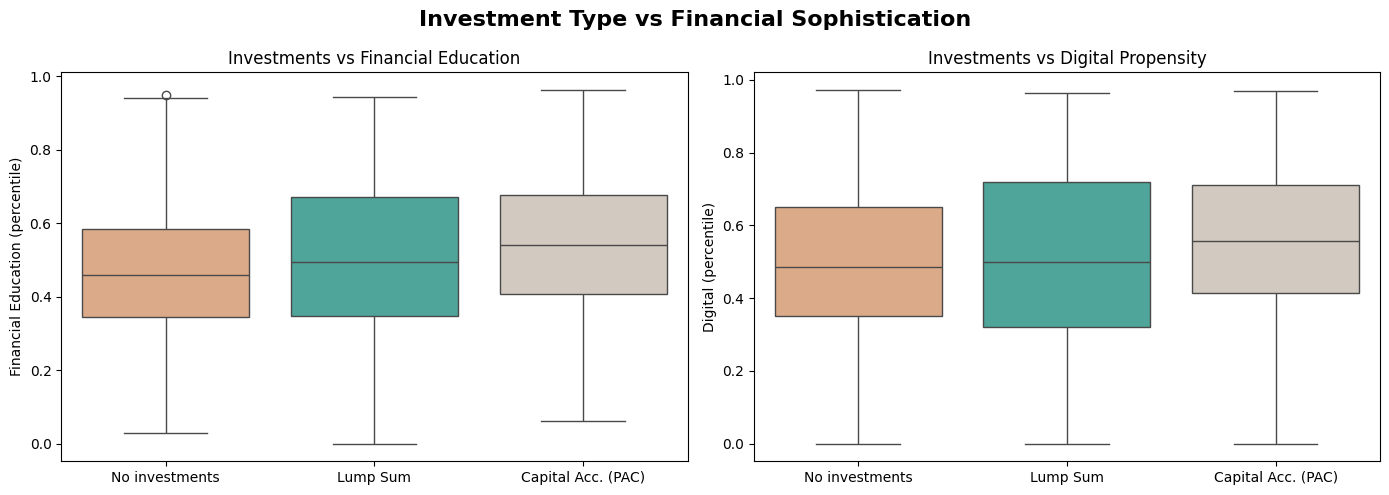

--- Mean FinEdu & Digital by Investment Type ---
                    FinEdu  Digital
Inv_L                              
No investments       0.469    0.500
Lump Sum             0.508    0.511
Capital Acc. (PAC)   0.538    0.555


In [138]:
# ── Investments vs FinEdu and Digital ─────────────────────────────────────────
inv_map = {1: 'No investments', 2: 'Lump Sum', 3: 'Capital Acc. (PAC)'}
df['Inv_L'] = df['Investments'].map(inv_map)
inv_order = ['No investments', 'Lump Sum', 'Capital Acc. (PAC)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Investment Type vs Financial Sophistication', fontsize=16, fontweight='bold')

# Investments vs FinEdu — violin plot (shows full distribution shape)
sns.boxplot(data=df, x='Inv_L', y='FinEdu', hue='Inv_L', ax=axes[0],
               palette=['#E8A87C','#D5CABD','#41B3A3'], order=inv_order)
axes[0].set_title('Investments vs Financial Education')
axes[0].set_xlabel('')
axes[0].set_ylabel('Financial Education (percentile)')

# Investments vs Digital — violin plot
sns.boxplot(data=df, x='Inv_L', y='Digital', hue='Inv_L', ax=axes[1],
               palette=['#E8A87C','#D5CABD','#41B3A3'], order=inv_order)
axes[1].set_title('Investments vs Digital Propensity')
axes[1].set_xlabel('')
axes[1].set_ylabel('Digital (percentile)')

plt.tight_layout()
plt.show()

print('--- Mean FinEdu & Digital by Investment Type ---')
print(df.groupby('Inv_L')[['FinEdu','Digital']].mean().round(3).loc[inv_order].to_string())

**Interpretation — Investments vs FinEdu & Digital:**

There is a clear monotonic gradient: clients investing in PAC (capital accumulation) plans have the highest financial education (0.538 vs 0.469 for non-investors) and digital propensity (0.555 vs 0.500). The violin shapes show that PAC investors are more concentrated in the upper range, while non-investors have a wider, flatter distribution skewed lower.

This makes intuitive sense: PAC plans require understanding of dollar-cost averaging, long-term investment horizons, and often digital platforms to manage regular payments. Lump-sum investors sit in between — they have enough financial knowledge to invest, but perhaps prefer a simpler, one-time approach.

*Takeaway*: Financial education and digital propensity are key drivers (or at least strong correlates) of investment sophistication. These variables will likely differentiate clusters.


### 2.5 Investment Behavior: Investments vs Age & Job

Do older or retired clients prefer different investment types? Does professional status influence investment choice?

**Important**: the heatmap is now normalized **by Job** (column-wise), so we read it as: *"Of all Managers, what % invests in PAC?"*. This is much more informative than normalizing by investment type, because job categories have very unequal sizes (3,284 employees vs only 107 entrepreneurs).

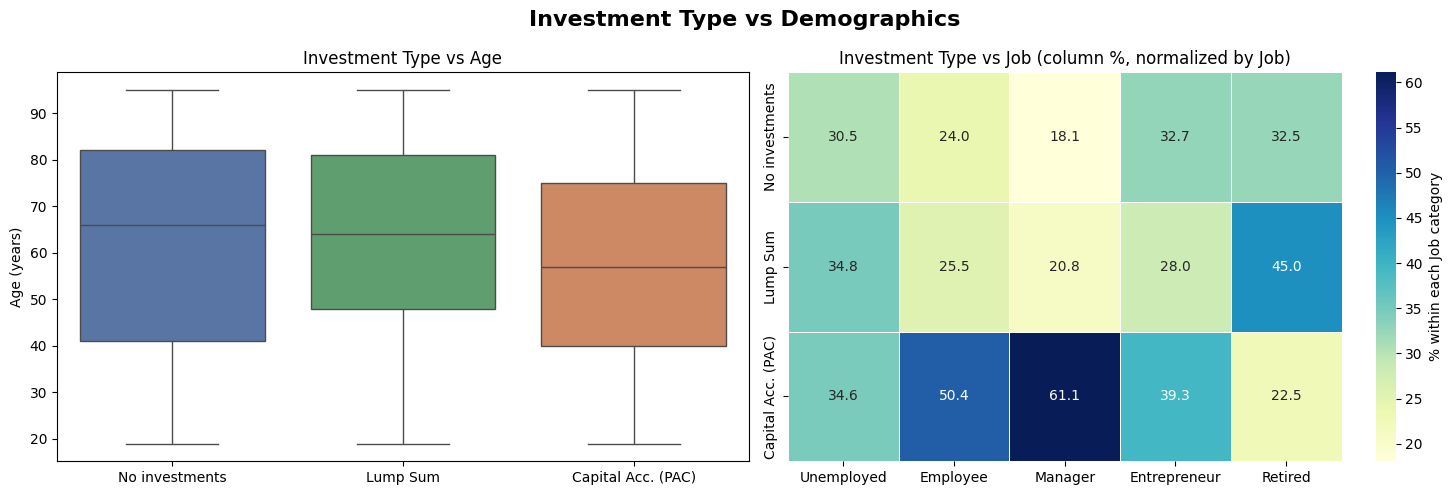

--- Median Age by Investment Type ---
                    median  mean
Inv_L                           
No investments        66.0  61.5
Lump Sum              64.0  63.2
Capital Acc. (PAC)    57.0  58.0

--- Job category sizes (for context) ---
Job_L
Unemployed       609
Employee        3284
Manager          144
Entrepreneur     107
Retired          856


In [139]:
# ── Investments vs Age and Job ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Investment Type vs Demographics', fontsize=16, fontweight='bold')

# Investments vs Age — boxplot
sns.boxplot(data=df, x='Inv_L', y='Age', hue='Inv_L', ax=axes[0],
            palette=['#4C72B0','#DD8452','#55A868'], order=inv_order, legend=False)
axes[0].set_title('Investment Type vs Age')
axes[0].set_xlabel('')
axes[0].set_ylabel('Age (years)')

# Investments vs Job — heatmap normalized BY JOB (column-wise)
# Reads: "Of all people with Job=X, what % invests in each type?"
inv_job_ct = pd.crosstab(df['Inv_L'], df['Job_L'], normalize='columns') * 100
job_order = ['Unemployed','Employee','Manager','Entrepreneur','Retired']
inv_job_ct = inv_job_ct.loc[inv_order, job_order]

sns.heatmap(inv_job_ct, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% within each Job category'})
axes[1].set_title('Investment Type vs Job (column %, normalized by Job)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('--- Median Age by Investment Type ---')
print(df.groupby('Inv_L')['Age'].agg(['median','mean']).round(1).loc[inv_order].to_string())
print('\n--- Job category sizes (for context) ---')
print(df['Job_L'].value_counts().loc[job_order].to_string())

**Interpretation — Investments vs Age & Job:**

**Age boxplot**: Non-investors are older (median ~66y) while PAC investors are younger (median ~57y). This reflects the financial lifecycle: younger working-age clients are in the accumulation phase and benefit from PAC (regular monthly investing), while older clients either already accumulated assets (lump sum) or don't invest at all.

**Heatmap (normalized by Job column)**: The heatmap now answers: *"Of all Managers, what percentage invests in PAC?"*
- **Managers** are the most investment-active: 61.1% use PAC plans — the highest rate of any profession. Only 18.1% don't invest.
- **Employees** are also PAC-oriented (50.4%), consistent with their salary-based income being suitable for regular monthly contributions.
- **Retired** clients overwhelmingly prefer Lump Sum (45%) — they have accumulated savings and invest them in bulk. Only 22.5% use PAC.
- **Unemployed and Entrepreneurs** show higher rates of non-investment (~31-33%), likely due to income instability.

*Takeaway*: Investment type is a strong signal for both age and profession. The clustering should naturally separate active PAC investors (younger, employed/managers) from conservative lump-sum investors (older, retired).

### 2.6 Investment Behavior: Investments vs Wealth & Saving Propensity

We plot the three investment types in **separate panels** in the Wealth-Saving space. This avoids the clutter of a single overlapping scatter and lets us compare the shape, center, and dispersion of each group independently.

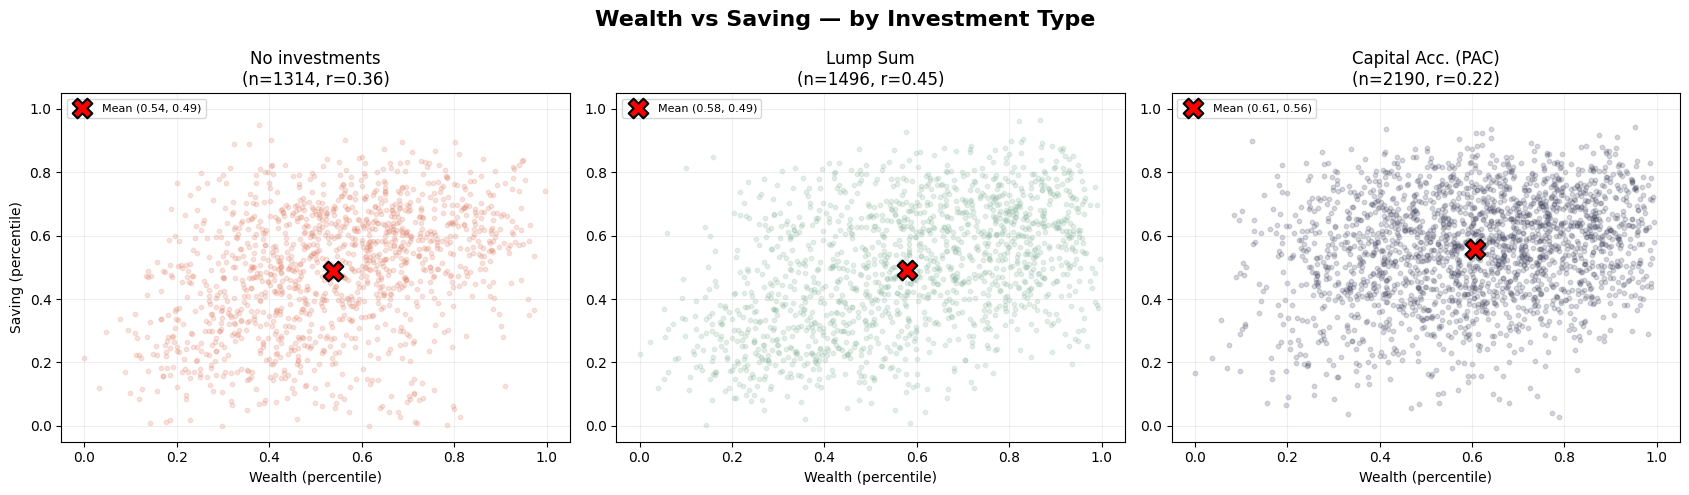

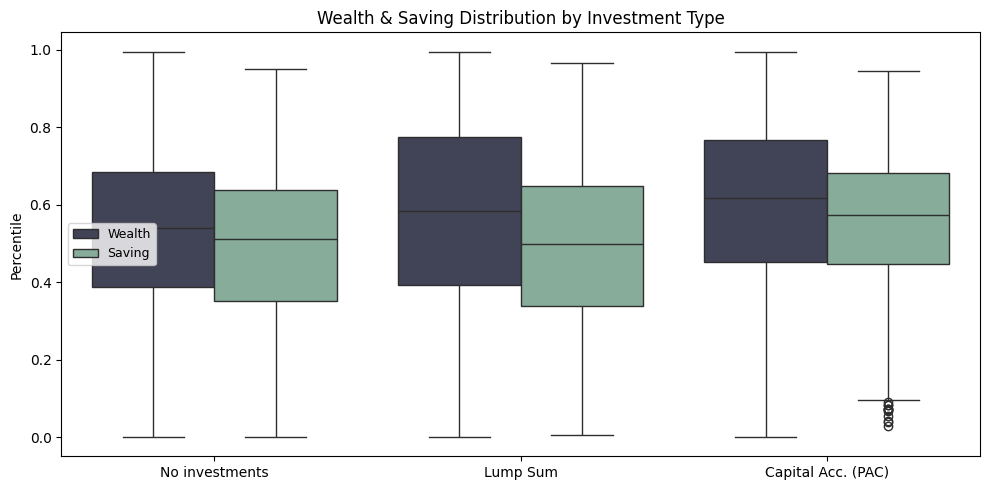

--- Mean Wealth & Saving by Investment Type ---
                    Wealth  Saving
Inv_L                             
No investments       0.537   0.489
Lump Sum             0.578   0.493
Capital Acc. (PAC)   0.606   0.560


In [140]:
# ── Investments vs Wealth and Saving — separate panels ─────────────────────────
inv_colors = {'No investments': '#E07A5F', 'Lump Sum': '#81B29A', 'Capital Acc. (PAC)': '#3D405B'}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Wealth vs Saving — by Investment Type', fontsize=16, fontweight='bold')
for idx, inv_type in enumerate(inv_order):
    mask = df['Inv_L'] == inv_type
    sub = df[mask]
    axes[idx].scatter(sub['Wealth'], sub['Saving'],
                      alpha=0.2, s=10, color=inv_colors[inv_type])
    axes[idx].set_xlabel('Wealth (percentile)')
    axes[idx].set_ylabel('Saving (percentile)' if idx == 0 else '')
    axes[idx].set_title(f'{inv_type}\n(n={mask.sum()}, r={sub["Wealth"].corr(sub["Saving"]):.2f})')
    axes[idx].set_xlim(-0.05, 1.05)
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].grid(True, alpha=0.2)
    axes[idx].scatter(sub['Wealth'].mean(), sub['Saving'].mean(),
                      s=200, marker='X', color='red', edgecolors='black',
                      linewidths=1.5, zorder=5,
                      label=f'Mean ({sub["Wealth"].mean():.2f}, {sub["Saving"].mean():.2f})')
    axes[idx].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

# ── Boxplot side-by-side: Wealth and Saving by Investment type ──────────────────
df_melted = df[['Inv_L', 'Wealth', 'Saving']].melt(
    id_vars='Inv_L', var_name='Variable', value_name='Value')

fig2, ax2 = plt.subplots(figsize=(10, 5))          # <-- nuova figura dedicata
sns.boxplot(data=df_melted, x='Inv_L', y='Value', hue='Variable',
            ax=ax2, palette=['#3D405B', '#81B29A'], order=inv_order)
ax2.set_title('Wealth & Saving Distribution by Investment Type')
ax2.set_xlabel('')
ax2.set_ylabel('Percentile')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('--- Mean Wealth & Saving by Investment Type ---')
print(df.groupby('Inv_L')[['Wealth', 'Saving']].mean().round(3).loc[inv_order].to_string())

**Interpretation — Wealth vs Saving by Investment Type (separate panels):**

Splitting into three panels reveals what was hidden in the overlapping scatter:

- **No investments** (left): the cloud is centered lower-left (mean Wealth=0.54, Saving=0.49), with a moderate positive Wealth-Saving correlation (r=0.36). These clients save and earn less — they are the least financially active segment.
- **Lump Sum** (center): the cloud shifts upward and rightward (mean Wealth=0.58, Saving=0.49), with the strongest correlation (r=0.45). The stronger correlation suggests that lump-sum investors are more 'rational' — their saving and wealth move together. However, Saving is similar to non-investors: lump-sum investors are wealthier but not necessarily bigger savers.
- **Capital Acc. (PAC)** (right): highest mean on both axes (Wealth=0.61, Saving=0.56), but the **weakest** correlation (r=0.22). This is the key insight — PAC investors save more **regardless of their wealth level**. The weaker correlation means even PAC clients with moderate wealth tend to save actively, which makes sense: PAC is designed for systematic accumulation, attracting disciplined savers at every income level.

*Takeaway*: PAC investors save more at every wealth level; lump-sum investors are wealthier but not better savers; non-investors are behind on both dimensions.

### 2.7 Family Dynamics: FamilySize vs Debt & Saving

Larger families might carry more debt — but do they save less? The data tells a more nuanced story.

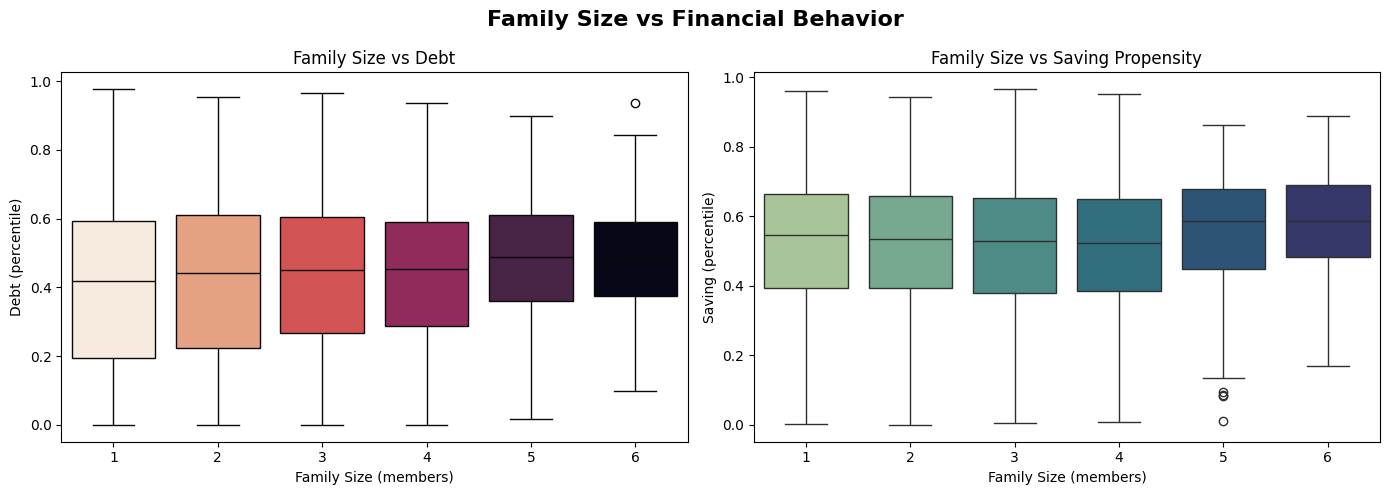

--- Financial profile by Family Size ---
            n_clients  avg_income  avg_debt  avg_saving  pct_pac
FamilySize                                                      
1                1607       0.593     0.407       0.521   42.502
2                1203       0.569     0.428       0.519   41.064
3                 996       0.563     0.436       0.511   45.683
4                 726       0.574     0.437       0.510   43.802
5                 271       0.564     0.481       0.558   47.232
6                 197       0.563     0.490       0.579   56.853


In [141]:
# ── FamilySize vs Debt and Saving ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Family Size vs Financial Behavior', fontsize=16, fontweight='bold')

# FamilySize vs Debt — boxplot
sns.boxplot(data=df, x='FamilySize', y='Debt', hue='FamilySize', ax=axes[0],
            palette='rocket_r', legend=False)
axes[0].set_title('Family Size vs Debt')
axes[0].set_xlabel('Family Size (members)')
axes[0].set_ylabel('Debt (percentile)')

# FamilySize vs Saving — boxplot
sns.boxplot(data=df, x='FamilySize', y='Saving', hue='FamilySize', ax=axes[1],
            palette='crest', legend=False)
axes[1].set_title('Family Size vs Saving Propensity')
axes[1].set_xlabel('Family Size (members)')
axes[1].set_ylabel('Saving (percentile)')

plt.tight_layout()
plt.show()

# Detailed table
fam_stats = df.groupby('FamilySize').agg(
    n_clients=('Debt', 'count'),
    avg_income=('Income', 'mean'),
    avg_debt=('Debt', 'mean'),
    avg_saving=('Saving', 'mean'),
    pct_pac=('Investments', lambda x: (x == 3).mean() * 100)
).round(3)
print('--- Financial profile by Family Size ---')
print(fam_stats.to_string())

**Interpretation — FamilySize vs Debt & Saving:**

The data reveals a seemingly paradoxical pattern: **larger families (5-6 members) both carry more debt AND save more**, roughly at the same income level.

This is not actually contradictory — it reflects the **economics of large families**:

1. **Higher debt is straightforward**: more family members means more expenses (housing, education, daily costs), leading to more borrowing. Average debt rises from 0.41 (single) to 0.49 (family of 6).

2. **Higher saving is the interesting part**. The likely explanation is **precautionary saving**: large families face greater financial risk (more dependents, higher expenses), so they are *more motivated* to build a safety buffer. They may also have stronger financial discipline driven by necessity — when you have 5-6 people depending on your income, you *must* plan ahead.

3. The correlation between FamilySize and Saving is very weak (r=0.037), meaning this is a mild effect, not a dominant one. The boxplots confirm that distributions overlap substantially.

4. An alternative explanation: large families in this dataset may slightly over-represent specific demographics (e.g. certain geographic areas or job types) that happen to save more. But the effect persists at roughly constant income (~0.56-0.59), so it's not purely an income confound.

*Takeaway*: FamilySize contributes mild but real information to financial behavior — it's not redundant with income or debt alone.

### 2.8 ESG Propensity: ESG vs Age & Wealth

ESG (Environmental, Social, Governance) awareness is a growing dimension in financial services. We use hexbin plots (density-colored scatter) to see where the mass of clients concentrates.

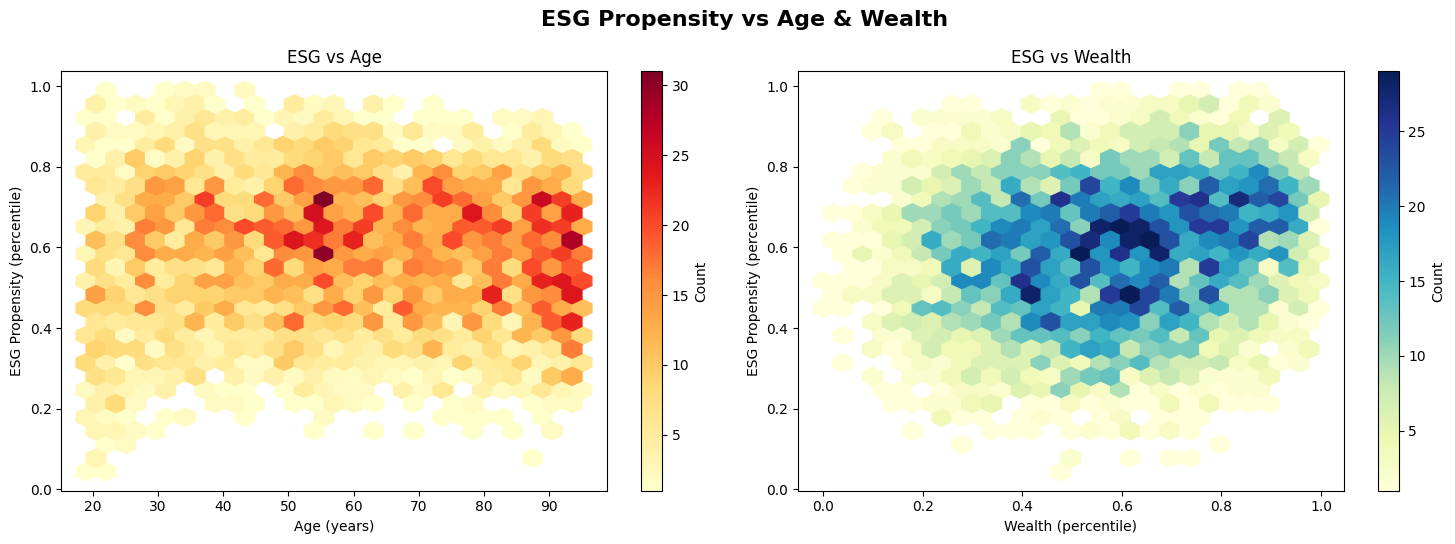

--- Correlations with ESG ---
  ESG vs Age:    r = -0.016
  ESG vs Wealth: r = 0.148
  ESG vs Income: r = 0.159
  ESG vs FinEdu: r = 0.177

--- Mean ESG by Age Group ---
         mean  count
AgeBin              
19-30   0.549    574
31-40   0.612    569
41-50   0.594    564
51-60   0.612    784
61-70   0.598    645
71-80   0.591    670
81-95   0.567   1194


In [142]:
# ── ESG vs Age and Wealth ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('ESG Propensity vs Age & Wealth', fontsize=16, fontweight='bold')

# ESG vs Age — hexbin density plot
hb1 = axes[0].hexbin(df['Age'], df['ESG'], gridsize=25, cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('ESG Propensity (percentile)')
axes[0].set_title('ESG vs Age')
plt.colorbar(hb1, ax=axes[0], label='Count')

# ESG vs Wealth — hexbin density plot
hb2 = axes[1].hexbin(df['Wealth'], df['ESG'], gridsize=25, cmap='YlGnBu', mincnt=1)
axes[1].set_xlabel('Wealth (percentile)')
axes[1].set_ylabel('ESG Propensity (percentile)')
axes[1].set_title('ESG vs Wealth')
plt.colorbar(hb2, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

# Detailed breakdown
print('--- Correlations with ESG ---')
print(f"  ESG vs Age:    r = {df['ESG'].corr(df['Age']):.3f}")
print(f"  ESG vs Wealth: r = {df['ESG'].corr(df['Wealth']):.3f}")
print(f"  ESG vs Income: r = {df['ESG'].corr(df['Income']):.3f}")
print(f"  ESG vs FinEdu: r = {df['ESG'].corr(df['FinEdu']):.3f}")

# ESG by age bins
df['AgeBin'] = pd.cut(df['Age'], bins=[18,30,40,50,60,70,80,96],
                       labels=['19-30','31-40','41-50','51-60','61-70','71-80','81-95'])
print('\n--- Mean ESG by Age Group ---')
print(df.groupby('AgeBin')['ESG'].agg(['mean','count']).round(3).to_string())
df = df.drop(columns=['AgeBin'])

**Interpretation — ESG vs Age & Wealth:**

**Left panel (ESG vs Age):** The hexbin plot shows client density in Age-ESG space. The darkest cells (most clients) sit around age 60-80 and ESG 0.5-0.7, but this simply reflects where most clients are demographically. The critical insight is that ESG propensity is **essentially flat across age** (r = −0.016, practically zero). If anything, the youngest clients (19-30) have the **lowest** mean ESG (0.549), while the 31-60 cohort peaks at ~0.61.

This might seem counterintuitive — aren't younger generations more ESG-conscious? In the general population, perhaps. But in a **bank client dataset**, ESG propensity is a *financial attitude measure*, not an opinion survey — it reflects whether a client actively considers ESG criteria in investment decisions. That requires a minimum level of financial sophistication that younger, less wealthy clients may not yet have developed. Young clients here are less likely to invest at all (see Section 2.3), so they have fewer opportunities to express ESG preferences through actual financial behavior.

**Right panel (ESG vs Wealth):** The pattern is clearer: the dense core of the hexbin cloud tilts upward as wealth increases (r = 0.148). The correlation extends to related variables: ESG correlates with Income (r=0.16), FinEdu (r=0.18), and Digital (r=0.15). **ESG investing behaves as a 'luxury good'**: when clients have enough wealth and financial literacy to think beyond basic returns, they can afford to incorporate sustainability preferences. Clients focused on making ends meet prioritize returns over ESG screens.

*Takeaway*: ESG propensity in this dataset is NOT driven by age, but by **financial sophistication and wealth**. It will cluster with Income, Wealth, FinEdu, and Digital — not with age. This means our affluent digital cluster (Cluster 3) will naturally show the highest ESG.

### 2.9 EDA Summary

**Key takeaways from the extended exploratory analysis:**

- **Geographic disparities** exist in income and wealth across Italian macro-regions, but are modest; debt is uniform. Area adds information but won't dominate clustering.
- **Investment behavior** is strongly linked to financial education and digital propensity — PAC investors are systematically more financially literate and digitally active.
- **Managers** are the most investment-active job category (61% use PAC); **retired clients** strongly prefer lump-sum; the **unemployed** and **entrepreneurs** show higher non-investment rates.
- **Older clients** tend toward lump-sum or no investments; PAC is more common among younger, employed clients — reflecting the financial lifecycle.
- **PAC investors** save more at every wealth level (not just because they're richer); the Wealth-Saving correlation is actually weakest for PAC users, suggesting systematic saving behavior independent of accumulated wealth.
- **Larger families** carry more debt but also save more — a precautionary saving effect driven by financial responsibility, not by income differences.
- **ESG awareness** is NOT driven by age (young clients are actually *less* ESG-aware in this dataset) but by **wealth and financial education** — it behaves as a 'luxury' financial attitude.

These patterns will resurface in the cluster profiles: the clustering algorithm should capture these natural groupings without being explicitly told about them.

In [143]:
# ── Clean up helper columns before proceeding to preprocessing ─────────────────
helper_cols = ['Area_L', 'Job_L', 'Inv_L']
for col in helper_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
print(f'Cleaned up. DataFrame shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Cleaned up. DataFrame shape: (5000, 17)
Columns: ['Age', 'Gender', 'Job', 'Area', 'CitySize', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving', 'Investments']


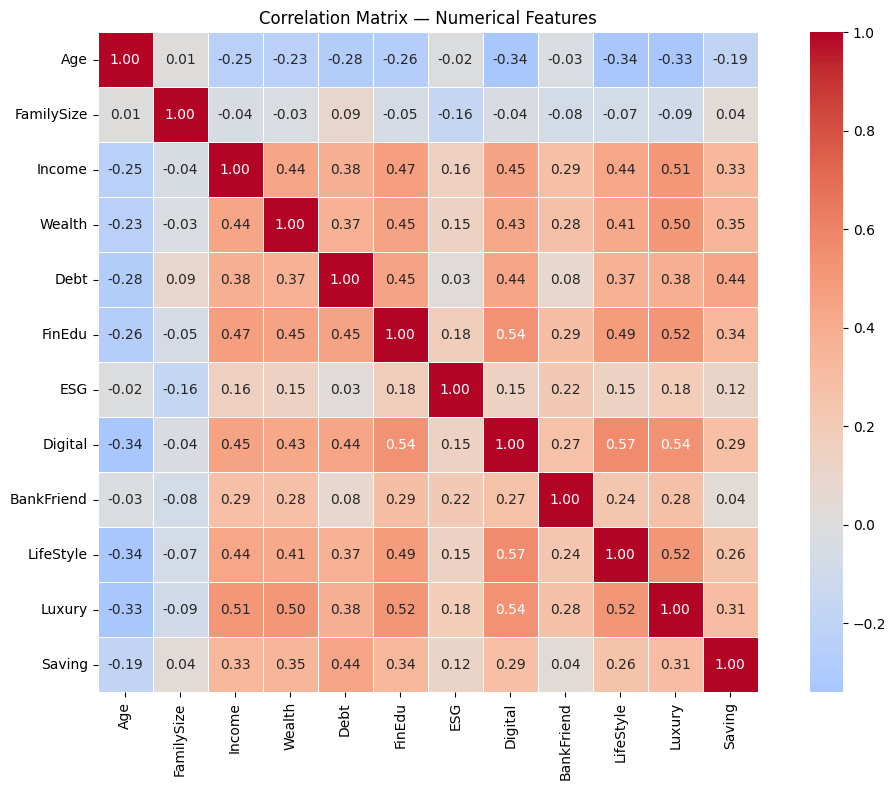

In [144]:
# ── Correlation heatmap (numerical features only) ─────────────────────────────
numerical_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt',
                  'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']

plt.figure(figsize=(11, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

## 3. Preprocessing

We split variables into:
- **Categorical**: `Gender`, `Job`, `Area`, `CitySize`, `Investments` → One-Hot Encoding
- **Numerical**: all others → MinMaxScaler (note: `Income`, `Wealth`, etc. are already normalized as percentiles, but `Age` and `FamilySize` are raw values and need scaling)

In [145]:
# ── Define categorical and numerical columns ───────────────────────────────────
categorical_columns = ['Gender', 'Job', 'Area', 'CitySize', 'Investments'] # per aggiungere CitySize alle categoriche bisogna modificare anche sotto

# BUG FIX: define categorical_features BEFORE using .astype()
categorical_features = df[categorical_columns].copy()
categorical_features = categorical_features.astype('category')

numerical_columns = [col for col in df.columns if col not in categorical_columns]
numerical_features = df[numerical_columns].copy()

print('Categorical columns:', categorical_columns)
print('Numerical columns:  ', numerical_columns)

Categorical columns: ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
Numerical columns:   ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']


In [146]:
# MODIFICATO PER NON NORMALIZZARE INUTILMENTE LE VARIABILI (GIÀ IN [0,1])

# ── Normalize numerical features ───────────────────────────────────────────────
# Only Age and FamilySize need scaling — all other numerical variables are
# already normalized as percentiles in [0, 1].
raw_cols = ['Age', 'FamilySize'] # modificare qui per CitySize categorica
percentile_cols = [c for c in numerical_columns if c not in raw_cols]
 
scaler = MinMaxScaler()
X_raw = scaler.fit_transform(numerical_features[raw_cols])
X_pct = numerical_features[percentile_cols].values   # already in [0,1]
 
X_num = np.hstack((X_raw, X_pct))
 
# ── One-Hot Encode categorical features ───────────────────────────────────────
# drop='first' applies dummy encoding (avoids multicollinearity)
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(categorical_features)
 
# ── Combine into final feature matrix ─────────────────────────────────────────
X = np.hstack((X_num, X_cat))
 
print(f'Numerical features shape : {X_num.shape}')
print(f'  ↳ Scaled (Age, FamilySize): {X_raw.shape[1]}')
print(f'  ↳ Percentiles (untouched) : {X_pct.shape[1]}')
print(f'Categorical features shape: {X_cat.shape}')
print(f'Combined X shape          : {X.shape}')

Numerical features shape : (5000, 12)
  ↳ Scaled (Age, FamilySize): 2
  ↳ Percentiles (untouched) : 10
Categorical features shape: (5000, 11)
Combined X shape          : (5000, 23)


## 4. Gower Distance

Standard distances (Euclidean, Manhattan) don't work well with mixed data.
**Gower Distance** handles both numerical (scaled absolute difference) and categorical (Jaccard) features, averaging them into a single distance in [0, 1].

This is the recommended approach from the course material.

In [147]:
# ── Compute Gower distance matrix ─────────────────────────────────────────────
# We pass the ORIGINAL dataframe (not one-hot encoded) so gower can detect
# which columns are categorical and apply the right sub-distance.

# Build a clean dataframe with correct dtypes for gower
df_gower = df.copy()
for col in categorical_columns:
    df_gower[col] = df_gower[col].astype('object')  # gower treats object as categorical

print('⏳ Computing Gower distance matrix (5000x5000) — this may take ~1-2 min...')
gower_distances = gower.gower_matrix(df_gower)
print(f'✅ Done. Distance matrix shape: {gower_distances.shape}')
print(f'   Min distance: {gower_distances[gower_distances > 0].min():.4f}')
print(f'   Max distance: {gower_distances.max():.4f}')
print(f'   Mean distance: {gower_distances.mean():.4f}')

⏳ Computing Gower distance matrix (5000x5000) — this may take ~1-2 min...
✅ Done. Distance matrix shape: (5000, 5000)
   Min distance: 0.0323
   Max distance: 0.7646
   Mean distance: 0.3415


## 5. Dimensionality Reduction: t-SNE with Gower Distance

We use t-SNE to visualize the high-dimensional data in 2D, using the precomputed Gower distance matrix.

⏳ Running t-SNE (2D) with Gower distance...
✅ t-SNE done.


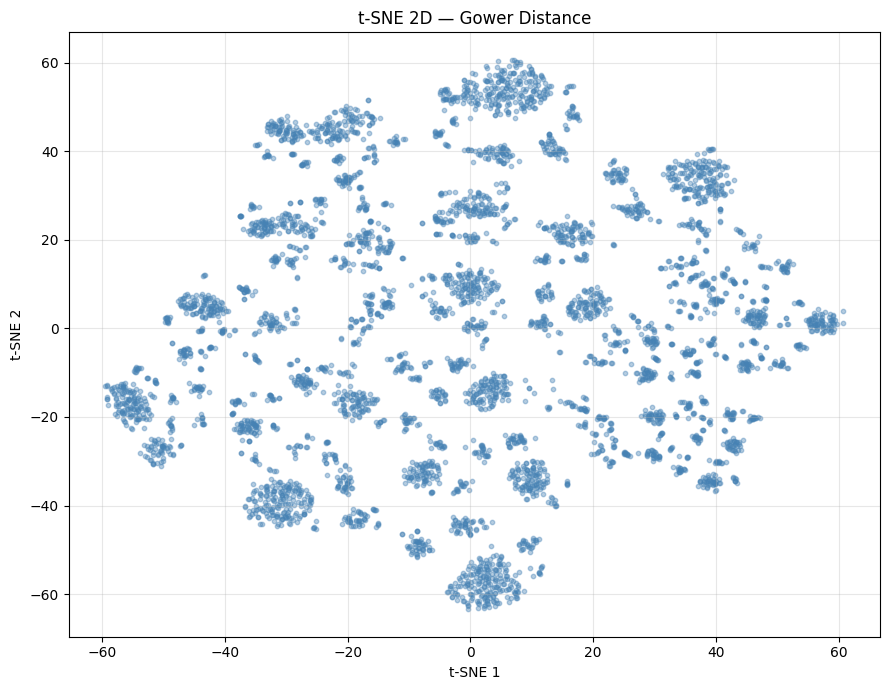

In [148]:
# ── t-SNE with Gower (2D) ─────────────────────────────────────────────────────
print('⏳ Running t-SNE (2D) with Gower distance...')
tsne_2d = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',
    random_state=42,
    perplexity=40,        # tuned: good balance for 5000 points
    learning_rate='auto'
)
Y_2d = tsne_2d.fit_transform(gower_distances)
print('✅ t-SNE done.')

plt.figure(figsize=(9, 7))
plt.scatter(Y_2d[:, 0], Y_2d[:, 1], alpha=0.4, s=10, c='steelblue')
plt.title('t-SNE 2D — Gower Distance')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [149]:
# ── Fit t-SNE in 3D ──────────────────────────────────────────────────────────
print('⏳ Running t-SNE (3D) with Gower distance...')
tsne_3d = TSNE(
    n_components=3,
    metric='precomputed',
    init='random',
    random_state=42,
    perplexity=40,
    learning_rate='auto'
)
Y_3d = tsne_3d.fit_transform(gower_distances)
print('✅ t-SNE 3D done.')

fig_explore = go.Figure(data=[go.Scatter3d(
    x=Y_3d[:, 0], y=Y_3d[:, 1], z=Y_3d[:, 2],
    mode='markers',
    marker=dict(size=2.5, color='steelblue', opacity=0.5),
)])
fig_explore.update_layout(
    title='t-SNE 3D — Gower Distance (exploration)',
    scene=dict(xaxis_title='t-SNE 1', yaxis_title='t-SNE 2', zaxis_title='t-SNE 3'),
    width=850, height=650,
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_explore.show()

⏳ Running t-SNE (3D) with Gower distance...
✅ t-SNE 3D done.


### 5.1 Perplexity Comparison

The **perplexity** hyperparameter controls how many neighbours each point considers when computing the embedding. It has a major impact on the visual output. Following the suggestion from the course notebooks, we compare four values to verify that `perplexity=40` produces the most informative structure for our 5000-point dataset.

- Low perplexity (5–10): very local structure, many small isolated blobs
- Medium (30–40): good balance — recommended range for datasets of this size
- High (50–100): more global structure, finer local detail is lost

> Note: each t-SNE run is independent. We are not refitting Y_2d — this is purely exploratory.

In [ ]:
# ── Perplexity comparison — 4 values side by side ─────────────────────────────
# Each run uses the same Gower precomputed matrix.
# Purpose: show that perplexity=40 is a deliberate, tuned choice.

perplexities = [10, 30, 40, 50]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('t-SNE — Perplexity Comparison (Gower Distance)', fontsize=14, fontweight='bold')

print('Running perplexity comparison...')
for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(
        n_components=2,
        metric='precomputed',
        init='random',
        random_state=42,
        perplexity=perp,
        learning_rate='auto'
    )
    Y_p = tsne_p.fit_transform(gower_distances)
    ax.scatter(Y_p[:, 0], Y_p[:, 1], alpha=0.3, s=6, c='steelblue')
    label = f'perplexity={perp}'
    if perp == 40:
        label += '  ← chosen'
        ax.set_facecolor('#f0f7ff')  # light blue background to highlight chosen value
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.3)
    print(f'  perplexity={perp} done.')

plt.tight_layout()
plt.show()
print('Perplexity=40 chosen: good separation of structures without over-fragmentation.')

### 5.2 Exploratory Colouring — Key Variables on t-SNE

Before clustering, we colour the t-SNE embedding by key individual variables to understand which features drive the visible structure. If a variable produces a clear gradient on the map, it is likely an important driver of the cluster separation.

In [ ]:
# ── t-SNE coloured by individual features (pre-clustering exploration) ─────────
# This shows which variables map onto the structural patterns visible in t-SNE.
# Use the already-computed Y_2d (perplexity=40).

explore_vars = ['Age', 'Income', 'Wealth', 'Digital', 'Saving']
fig, axes = plt.subplots(1, len(explore_vars), figsize=(22, 4))
fig.suptitle('t-SNE 2D — Coloured by Individual Features (pre-clustering)', fontsize=13, fontweight='bold')

for ax, var in zip(axes, explore_vars):
    # Use normalised values for consistent colour scale
    if var in df.columns:
        values = df[var].values
        # Normalise to [0,1] for colour mapping if not already
        v_norm = (values - values.min()) / (values.max() - values.min() + 1e-9)
        sc = ax.scatter(Y_2d[:, 0], Y_2d[:, 1],
                        c=v_norm, cmap='RdYlGn',
                        alpha=0.4, s=6)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(var, fontsize=11)
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Variables with a clear gradient on t-SNE are the main drivers of cluster separation.')

## 6. Choosing the Number of Clusters (Elbow + Silhouette)

We try K-Medoids with different values of k and evaluate:
- **Inertia** (Elbow method): lower = tighter clusters
- **Silhouette Score**: higher = better-separated clusters (range: -1 to 1)

In [150]:
# ── Elbow + Silhouette for K-Medoids ──────────────────────────────────────────
k_range = range(2, 9)
inertias = []
silhouettes = []

print('⏳ Testing k from 2 to 8...')
for k in k_range:
    kmed = KMedoids(
        n_clusters=k,
        metric='precomputed',
        method='pam',          # PAM = most robust k-medoids variant
        init='build',   # smart initialization (like k-means++)
        random_state=42
    )
    labels = kmed.fit_predict(gower_distances)
    inertias.append(kmed.inertia_)
    sil = silhouette_score(gower_distances, labels, metric='precomputed')
    silhouettes.append(sil)
    print(f'  k={k} | Inertia: {kmed.inertia_:.2f} | Silhouette: {sil:.4f}')

print('✅ Done.')

⏳ Testing k from 2 to 8...
  k=2 | Inertia: 1197.83 | Silhouette: 0.1356
  k=3 | Inertia: 1090.27 | Silhouette: 0.1340
  k=4 | Inertia: 1018.65 | Silhouette: 0.1463
  k=5 | Inertia: 980.60 | Silhouette: 0.1278
  k=6 | Inertia: 944.00 | Silhouette: 0.1157
  k=7 | Inertia: 917.56 | Silhouette: 0.1236
  k=8 | Inertia: 893.13 | Silhouette: 0.1155
✅ Done.


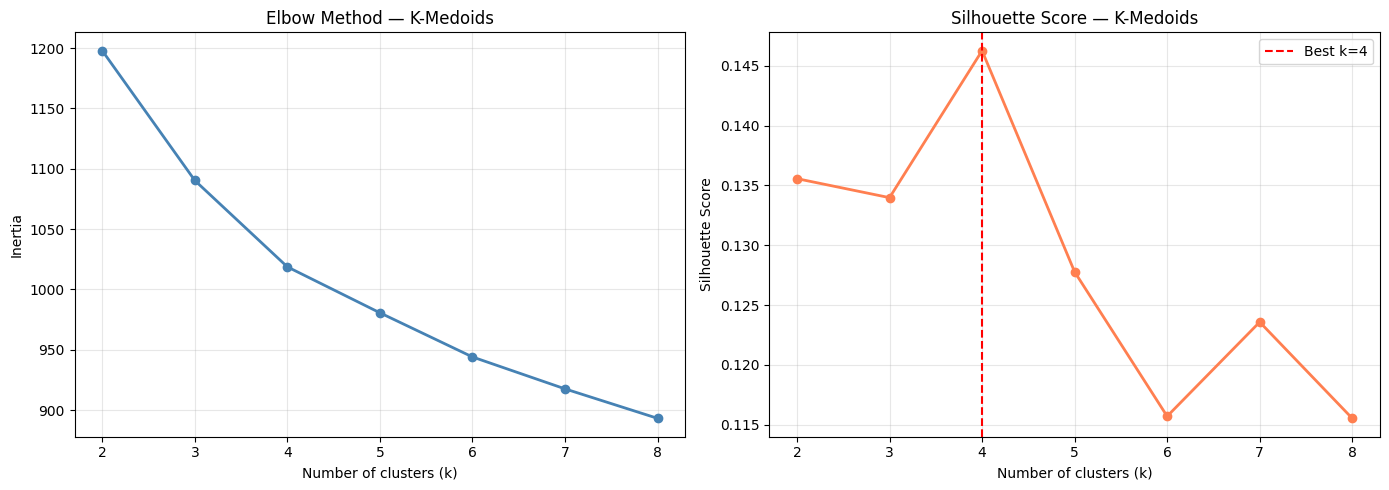

→ Best k by Silhouette: k=4


In [151]:
# ── Plot Elbow and Silhouette ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — K-Medoids')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), silhouettes, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score — K-Medoids')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Mark best silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'→ Best k by Silhouette: k={best_k}')

## 7. K-Medoids Clustering (Final Model)

We fit K-Medoids with the best k found above, using the Gower precomputed distance matrix.

In [152]:
# ── Final K-Medoids model ──────────────────────────────────────────────────────
# You can override best_k here if domain knowledge suggests a different value
N_CLUSTERS = 4  # set best_kor set manually e.g. N_CLUSTERS = 4

kmed_final = KMedoids(
    n_clusters=N_CLUSTERS,
    metric='precomputed',
    method='pam',
    init='build',
    random_state=42
)

print(f'⏳ Fitting K-Medoids with k={N_CLUSTERS}...')
cluster_labels = kmed_final.fit_predict(gower_distances)
print('✅ Clustering done.')

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Cluster sizes
print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

⏳ Fitting K-Medoids with k=4...
✅ Clustering done.

Cluster sizes:
Cluster
0    1681
1    1257
2     865
3    1197
Name: count, dtype: int64


## 8. Visualize Clusters with t-SNE

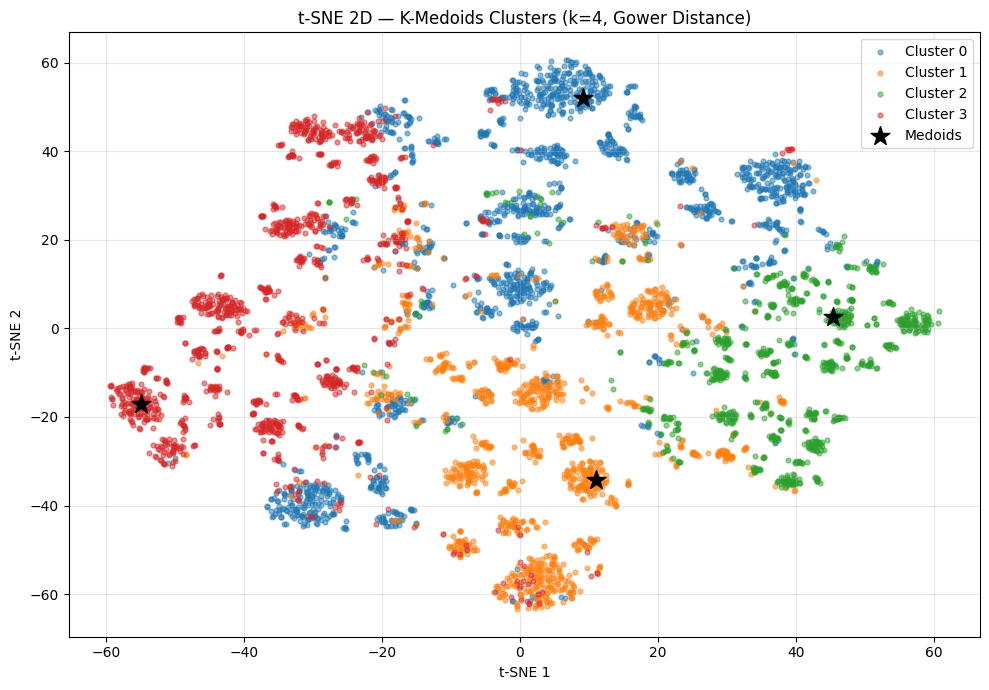

In [153]:
# ── t-SNE coloured by cluster ──────────────────────────────────────────────────
palette = sns.color_palette('tab10', N_CLUSTERS)

plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    plt.scatter(Y_2d[mask, 0], Y_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=12,
                color=palette[c])

# Mark medoids
medoid_indices = kmed_final.medoid_indices_
plt.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
            s=200, marker='*', c='black', zorder=5, label='Medoids')

plt.title(f't-SNE 2D — K-Medoids Clusters (k={N_CLUSTERS}, Gower Distance)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [154]:
tsne_3d_df = pd.DataFrame({
    'tSNE_1': Y_3d[:, 0],
    'tSNE_2': Y_3d[:, 1],
    'tSNE_3': Y_3d[:, 2],
    'Cluster': cluster_labels.astype(str)
})

fig_clusters = px.scatter_3d(
    tsne_3d_df, x='tSNE_1', y='tSNE_2', z='tSNE_3',
    color='Cluster',
    title=f't-SNE 3D — K-Medoids Clusters (k={N_CLUSTERS}, Gower Distance)',
    opacity=0.5,
    color_discrete_sequence=px.colors.qualitative.T10
)
fig_clusters.update_traces(marker=dict(size=2.5))

# ── Mark medoids ──────────────────────────────────────────────────────────────
fig_clusters.add_trace(go.Scatter3d(
    x=Y_3d[medoid_indices, 0],
    y=Y_3d[medoid_indices, 1],
    z=Y_3d[medoid_indices, 2],
    mode='markers',
    marker=dict(size=8, color='black', symbol='diamond'),
    name='Medoids'
))

fig_clusters.update_layout(
    width=850, height=650,
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_clusters.show()

### 8.1 Confidence Ellipses

To better visualise how compact and separated each cluster is, we overlay **confidence ellipses** on the 2D t-SNE plot. Each ellipse is drawn at 2 standard deviations and captures approximately 95% of the cluster's points. Tighter ellipses = more cohesive clusters; overlapping ellipses = borderline regions between segments.

In [ ]:
# ── Confidence ellipses on t-SNE 2D ──────────────────────────────────────────
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """Draw a covariance confidence ellipse for points (x, y)."""
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# ── Assign persona labels (update these after reading cluster profiles) ────────
PERSONA_LABELS = {
    0: 'Cluster 0',   # e.g. 'Young Mass'
    1: 'Cluster 1',   # e.g. 'Mass Affluent'
    2: 'Cluster 2',   # e.g. 'Affluent'
    3: 'Cluster 3',   # e.g. 'Retired Saver'
}

palette = sns.color_palette('tab10', N_CLUSTERS)
fig, ax = plt.subplots(figsize=(11, 8))

for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    x_c = Y_2d[mask, 0]
    y_c = Y_2d[mask, 1]
    label = PERSONA_LABELS.get(c, f'Cluster {c}')
    ax.scatter(x_c, y_c, label=label, alpha=0.4, s=10, color=palette[c])
    if len(x_c) > 2:
        confidence_ellipse(x_c, y_c, ax, n_std=2.0,
                           edgecolor=palette[c], linewidth=2,
                           linestyle='--', alpha=0.8)
    # Cluster label at centroid
    ax.text(np.mean(x_c), np.mean(y_c), label,
            fontsize=9, fontweight='bold', ha='center',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=palette[c], alpha=0.8))

# Medoids
ax.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
           s=220, marker='*', c='black', zorder=6, label='Medoids')

ax.set_title(f't-SNE 2D — Clusters with Confidence Ellipses (k={N_CLUSTERS})', fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Ellipses drawn at 2 std (≈95% of cluster points). Overlap indicates borderline clients.')

### 8.2 Borderline Clients — Silhouette-Based Highlighting

Clients with a **low or negative silhouette score** are the most ambiguous — they sit between two clusters and could plausibly belong to either. Visualising them on the t-SNE map helps identify transition zones and understand the limits of the segmentation.

In [ ]:
# ── Borderline clients: low silhouette highlighted on t-SNE ───────────────────
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(gower_distances, cluster_labels, metric='precomputed')
THRESHOLD = 0.05   # clients below this are considered borderline

borderline = sil_vals < THRESHOLD
print(f'Borderline clients (silhouette < {THRESHOLD}): {borderline.sum()} '
      f'({borderline.mean()*100:.1f}% of total)')

fig, ax = plt.subplots(figsize=(11, 8))

# Plot normal clients
for c in range(N_CLUSTERS):
    mask = (cluster_labels == c) & ~borderline
    ax.scatter(Y_2d[mask, 0], Y_2d[mask, 1],
               label=PERSONA_LABELS.get(c, f'Cluster {c}'),
               alpha=0.4, s=10, color=palette[c])

# Overlay borderline clients in grey
ax.scatter(Y_2d[borderline, 0], Y_2d[borderline, 1],
           alpha=0.7, s=18, color='lightgray', edgecolors='dimgray',
           linewidth=0.5, zorder=4, label=f'Borderline (sil < {THRESHOLD})')

# Medoids
ax.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
           s=220, marker='*', c='black', zorder=6, label='Medoids')

ax.set_title(f't-SNE 2D — Borderline Clients Highlighted (k={N_CLUSTERS})', fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution of borderline clients across clusters
print('\nBorderline clients per cluster:')
for c in range(N_CLUSTERS):
    n_border = ((cluster_labels == c) & borderline).sum()
    n_total  = (cluster_labels == c).sum()
    print(f'  Cluster {c}: {n_border}/{n_total} ({n_border/n_total*100:.1f}%)')

## 9. PCA — Dimensionality Reduction & Cluster Visualization

PCA is applied on the encoded feature matrix X (numerical + one-hot categorical) for visualization. Unlike t-SNE, PCA is linear and lets us inspect which variables drive variance.

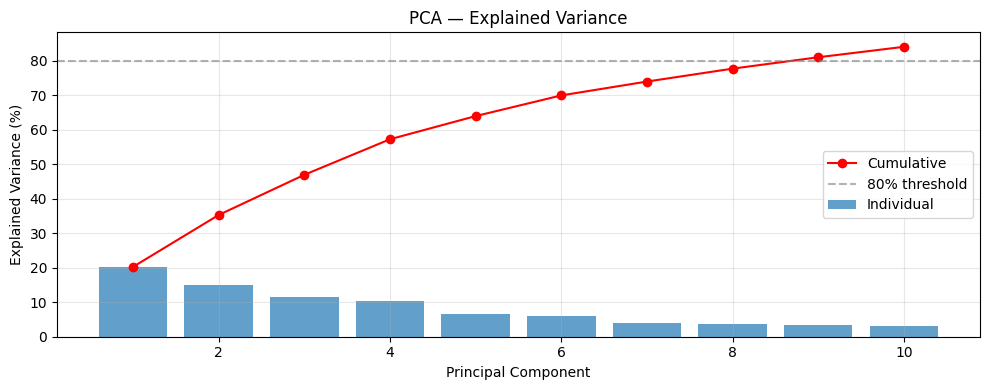

Cumulative explained variance:
  PC1–PC1: 20.3%
  PC1–PC2: 35.3%
  PC1–PC3: 47.0%
  PC1–PC4: 57.3%
  PC1–PC5: 64.0%
  PC1–PC6: 70.0%
  PC1–PC7: 74.0%
  PC1–PC8: 77.8%
  PC1–PC9: 81.1%
  PC1–PC10: 84.1%


In [155]:
# ── PCA ────────────────────────────────────────────────────────────────────────
pca = PCA(n_components=10, random_state=42)
X_pca_full = pca.fit_transform(X)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), explained * 100, alpha=0.7, label='Individual')
plt.plot(range(1, 11), cumulative * 100, marker='o', color='red', label='Cumulative')
plt.axhline(80, linestyle='--', color='gray', alpha=0.6, label='80% threshold')
plt.title('PCA — Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Cumulative explained variance:')
for i, c in enumerate(cumulative):
    print(f'  PC1–PC{i+1}: {c*100:.1f}%')

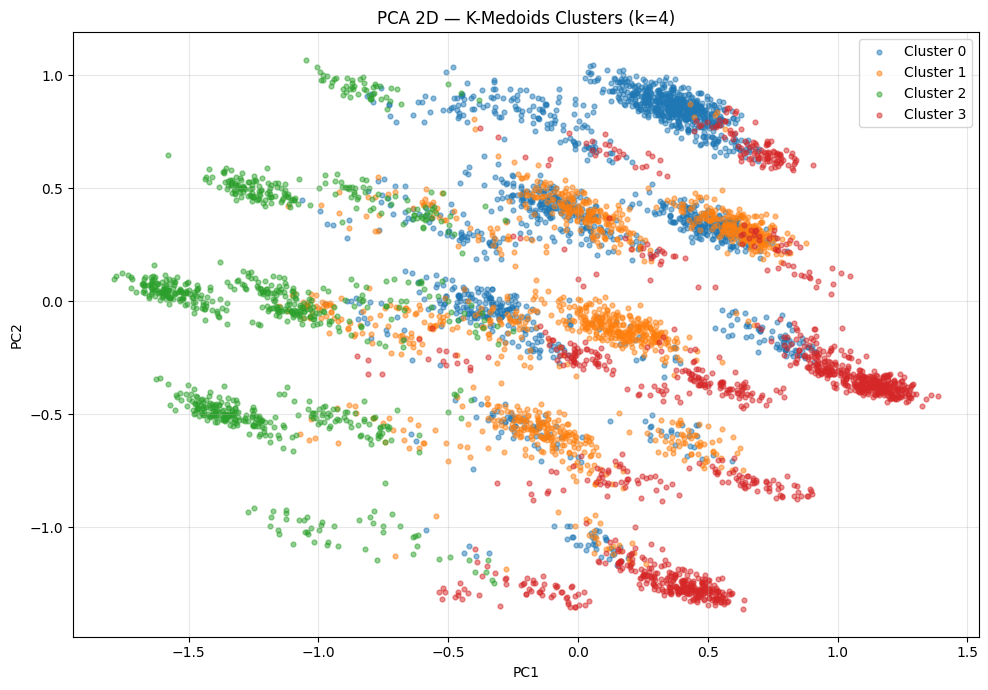

In [156]:
# ── PCA 2D scatter coloured by cluster ────────────────────────────────────────
X_pca_2d = X_pca_full[:, :2]

plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=12,
                color=palette[c])

plt.title(f'PCA 2D — K-Medoids Clusters (k={N_CLUSTERS})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

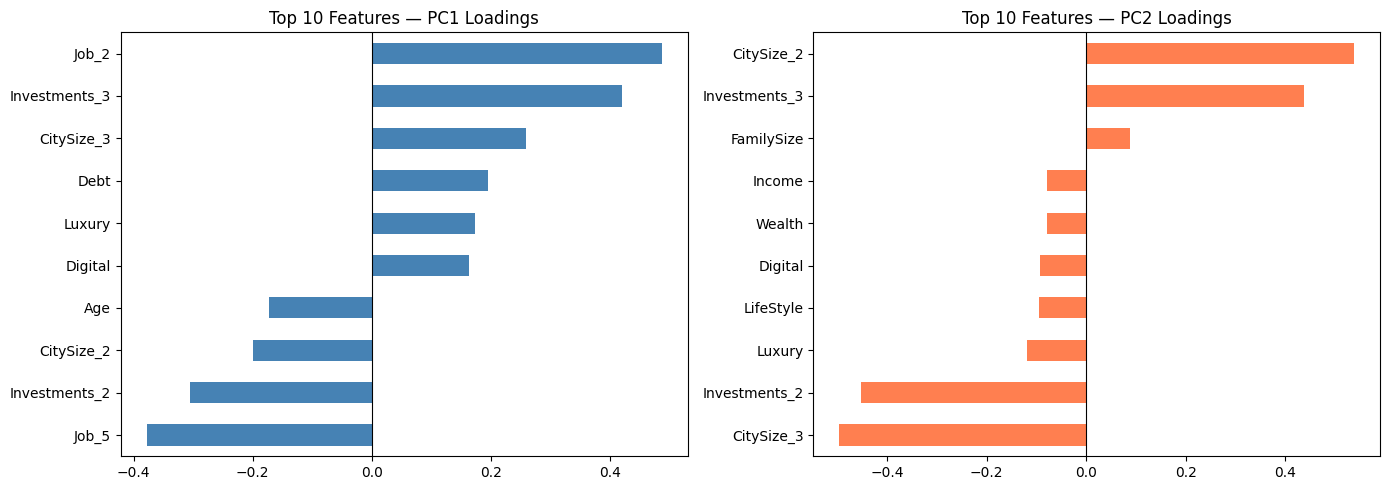

In [157]:
# ── PCA Loadings — which variables drive PC1 and PC2? ─────────────────────────
feature_names_num = numerical_columns
feature_names_cat = encoder.get_feature_names_out(categorical_columns).tolist()
all_feature_names = feature_names_num + feature_names_cat

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=all_feature_names,
    columns=['PC1', 'PC2']
)

# Top 10 features by absolute loading on PC1
top_pc1 = loadings['PC1'].abs().nlargest(10).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings.loc[top_pc1, 'PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Features — PC1 Loadings')
axes[0].axvline(0, color='black', linewidth=0.8)

top_pc2 = loadings['PC2'].abs().nlargest(10).index
loadings.loc[top_pc2, 'PC2'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Features — PC2 Loadings')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 10. Cluster Profiling & Interpretation

We analyse the mean/mode of each variable per cluster to understand what characterises each segment.

In [158]:
# ── Cluster profiles — numerical means ────────────────────────────────────────
profile_num = df.groupby('Cluster')[numerical_columns].mean().round(3)
print('--- Cluster Profiles (Numerical — Normalized Means) ---')
display(profile_num.T)

--- Cluster Profiles (Numerical — Normalized Means) ---


Cluster,0,1,2,3
Age,60.111,58.056,78.754,50.215
FamilySize,2.924,2.628,2.037,2.057
Income,0.560,0.548,0.392,0.760
Wealth,0.579,0.533,0.395,0.762
Debt,0.465,0.456,0.144,0.557
FinEdu,0.495,0.479,0.341,0.689
ESG,0.550,0.527,0.620,0.679
Digital,0.502,0.499,0.319,0.744
BankFriend,0.583,0.558,0.636,0.721
LifeStyle,0.430,0.446,0.265,0.667


In [159]:
# ── Cluster profiles — categorical modes ──────────────────────────────────────
job_map  = {1:'Unemployed', 2:'Employee', 3:'Manager', 4:'Entrepreneur', 5:'Retired'}
area_map = {1:'Nord', 2:'Centro', 3:'Sud/Isole'}
city_map = {1:'Small', 2:'Medium', 3:'Large'}
inv_map  = {1:'No invest.', 2:'Lump Sum', 3:'Capital Acc.'}
gen_map  = {0:'Male', 1:'Female'}

df['Job_L']  = df['Job'].map(job_map)
df['Area_L'] = df['Area'].map(area_map)
df['City_L'] = df['CitySize'].map(city_map)
df['Inv_L']  = df['Investments'].map(inv_map)
df['Gen_L']  = df['Gender'].map(gen_map)

profile_cat = df.groupby('Cluster')[['Gen_L','Job_L','Area_L','City_L','Inv_L']].agg(lambda x: x.mode()[0])
print('--- Cluster Profiles (Categorical — Mode) ---')
display(profile_cat)

--- Cluster Profiles (Categorical — Mode) ---


,Gen_L,Job_L,Area_L,City_L,Inv_L
Cluster,,,,,
0,Female,Employee,Nord,Medium,Capital Acc.
1,Male,Employee,Nord,Small,No invest.
2,Female,Retired,Nord,Medium,Lump Sum
3,Male,Employee,Nord,Large,Capital Acc.


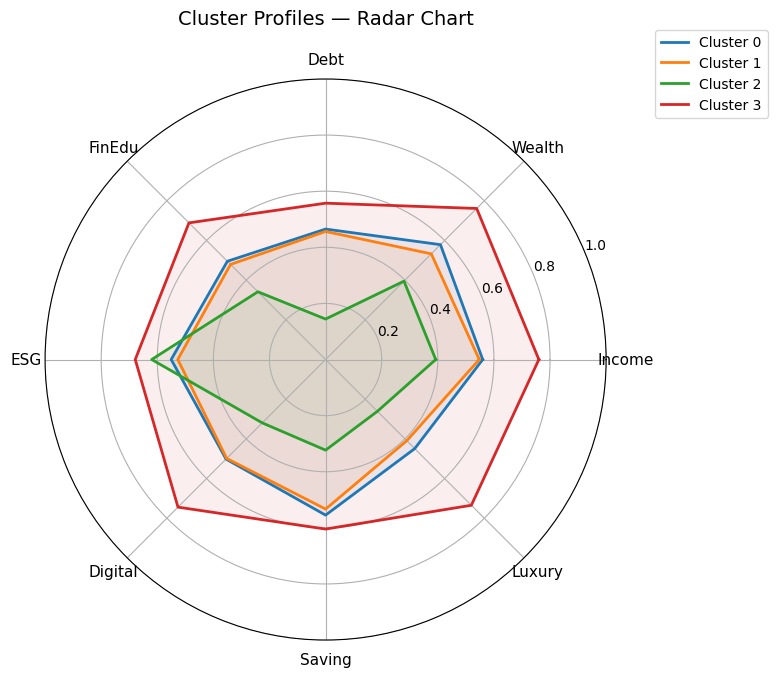

In [160]:
# ── Radar chart: cluster profiles on key numerical variables ──────────────────
key_vars = ['Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'Saving', 'Luxury']
cluster_means = df.groupby('Cluster')[key_vars].mean()

angles = np.linspace(0, 2 * np.pi, len(key_vars), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in range(N_CLUSTERS):
    values = cluster_means.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {c}', linewidth=2, color=palette[c])
    ax.fill(angles, values, alpha=0.08, color=palette[c])

ax.set_thetagrids(np.degrees(angles[:-1]), key_vars, size=11)
ax.set_ylim(0, 1)
ax.set_title('Cluster Profiles — Radar Chart', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

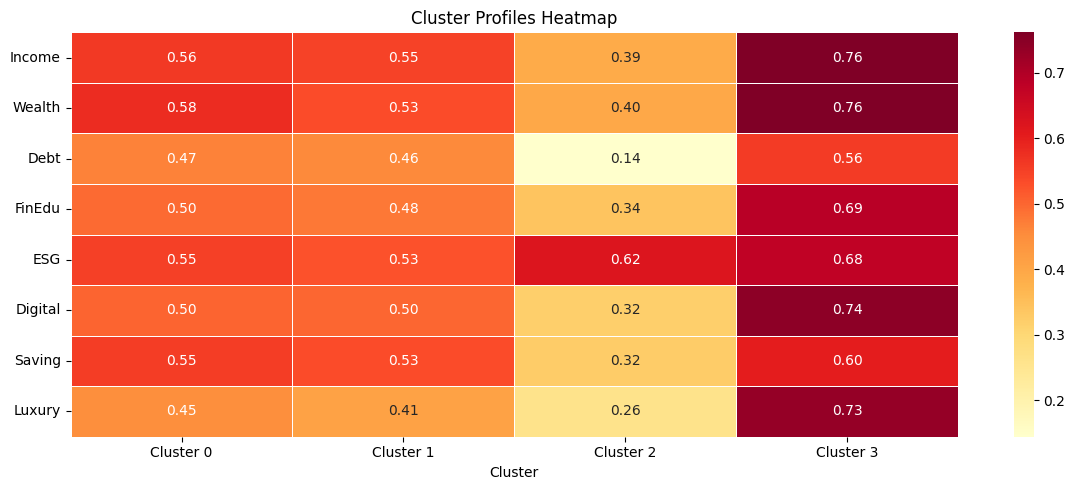

In [161]:
# ── Heatmap of cluster profiles ────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_means[key_vars].T,
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            xticklabels=[f'Cluster {c}' for c in range(N_CLUSTERS)],
            linewidths=0.5)
plt.title('Cluster Profiles Heatmap')
plt.tight_layout()
plt.show()

In [162]:
# ── Medoid profiles — the representative client of each cluster ───────────────
medoid_profiles = df.iloc[kmed_final.medoid_indices_].copy().reset_index(drop=True)
medoid_profiles.index.name = 'Cluster'
print('--- Medoid Profiles (Representative Client per Cluster) ---')
display(medoid_profiles[numerical_columns + ['Gen_L','Job_L','Area_L','City_L','Inv_L']])

--- Medoid Profiles (Representative Client per Cluster) ---


,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Gen_L,Job_L,Area_L,City_L,Inv_L
Cluster,,,,,,,,,,,,,,,,,
0,70,3,0.442296,0.667260,0.373311,0.529557,0.622244,0.379909,0.701953,0.312721,0.439937,0.532308,Female,Employee,Nord,Medium,Capital Acc.
1,53,1,0.606499,0.418081,0.443457,0.556508,0.544906,0.487718,0.569354,0.599387,0.314667,0.519828,Male,Employee,Nord,Small,No invest.
2,73,1,0.407312,0.228185,0.194438,0.381688,0.731963,0.335502,0.720185,0.219611,0.204991,0.253147,Female,Retired,Nord,Medium,Lump Sum
3,51,2,0.817226,0.812271,0.540330,0.660666,0.740343,0.712418,0.711609,0.742132,0.869339,0.711956,Male,Employee,Nord,Large,Capital Acc.


## 11. Summary & Business Interpretation

Based on the cluster profiles observed above, we assign a meaningful business label to each segment.

---

### Cluster 0 — "The Working Saver" 👩‍💼
**Profile:** Female, Employee, Nord, Medium city, Capital Accumulation (PAC)
| Feature | Value | Interpretation |
|---------|-------|----------------|
| Age | 60.1 | Late working age / pre-retirement |
| Income | 0.560 | Above average |
| Wealth | 0.579 | Above average |
| Debt | 0.465 | Moderate |
| FinEdu | 0.495 | Average financial education |
| Digital | 0.502 | Average digital propensity |
| Saving | 0.555 | Good saving propensity |
| Investments | Capital Acc. | Regular PAC investor |

**Business Interpretation:** This is the core working-class segment — employed women in northern medium-sized cities, approaching retirement with a steady PAC investment habit. They have moderate financial literacy and digital engagement but are reliable, consistent investors.

**Recommended services:** PAC plans with automatic management, retirement planning tools, life insurance, pension supplements.

**Service model:** Mixed digital + physical branch.

---

### Cluster 1 — "The Cautious Male" 👨
**Profile:** Male, Employee, Nord, Small city, No investments
| Feature | Value | Interpretation |
|---------|-------|----------------|
| Age | 58.1 | Late working age |
| Income | 0.548 | Average |
| Wealth | 0.533 | Average |
| Debt | 0.456 | Moderate |
| FinEdu | 0.479 | Below average financial education |
| Digital | 0.499 | Average digital propensity |
| Saving | 0.533 | Moderate saving |
| Investments | No invest. | Not currently investing |

**Business Interpretation:** This is the most important segment from a business opportunity perspective. They have decent income and savings but are **not investing** — likely due to below-average financial education and risk aversion. They are the primary target for financial education campaigns and first investment products.

**Recommended services:** Low-risk entry-level investment products, financial education content, simple savings accounts with returns, guaranteed capital products.

**Service model:** Physical branch + call center (low digital propensity).

---

### Cluster 2 — "The Retired Conservative" 👴
**Profile:** Female, Retired, Nord, Medium city, Lump Sum
| Feature | Value | Interpretation |
|---------|-------|----------------|
| Age | 78.8 | Elderly / fully retired |
| Income | 0.392 | Below average (pension income) |
| Wealth | 0.395 | Below average |
| Debt | 0.144 | Very low debt |
| FinEdu | 0.341 | Low financial education |
| Digital | 0.319 | Low digital propensity |
| Saving | 0.323 | Low saving (decumulation phase) |
| Investments | Lump Sum | One-time investment preference |

**Business Interpretation:** Elderly retired women with very low debt (mortgages paid off), low income from pensions, and minimal digital engagement. They prefer simple, one-time lump-sum investments and need capital protection. They are in the **decumulation phase** of their financial lifecycle.

**Recommended services:** Capital protection products, low-risk bonds, inheritance planning, long-term care insurance, estate planning.

**Service model:** Physical branch only (very low digital propensity).

---

### Cluster 3 — "The Affluent Digital Professional" 👨‍💻
**Profile:** Male, Employee, Nord, Large city, Capital Accumulation (PAC)
| Feature | Value | Interpretation |
|---------|-------|----------------|
| Age | 50.2 | Prime working age |
| Income | 0.760 | High income |
| Wealth | 0.762 | High wealth |
| Debt | 0.557 | Higher debt (likely mortgage) |
| FinEdu | 0.689 | High financial education |
| Digital | 0.744 | High digital propensity |
| ESG | 0.679 | High ESG awareness |
| Luxury | 0.735 | High lifestyle/luxury spending |
| Saving | 0.604 | Strong saving propensity |
| Investments | Capital Acc. | Active PAC investor |

**Business Interpretation:** This is the most financially sophisticated and profitable segment — high-income men in large northern cities, digitally native, highly educated financially, with strong ESG awareness. They actively invest through PAC plans and have significant wealth. The higher debt likely reflects mortgages on high-value properties, not financial distress.

**Recommended services:** Advanced investment portfolios, ESG funds, premium banking, wealth management, multi-asset PAC plans, premium credit cards, mortgage refinancing.

**Service model:** Primarily digital (app, online banking), with premium relationship manager access.

---

### Segment Overview

| Cluster | Label | Size | Key Opportunity |
|---------|-------|------|----------------|
| 0 | The Working Saver | 1,681 (33.6%) | Deepen PAC engagement, retirement planning |
| 1 | The Cautious Male | 1,257 (25.1%) | Convert to first investment — highest growth potential |
| 2 | The Retired Conservative | 865 (17.3%) | Capital protection, inheritance, LTC insurance |
| 3 | The Affluent Digital Professional | 1,197 (23.9%) | Premium services, ESG portfolios, wealth management |


In [163]:
# ── Final model quality summary ────────────────────────────────────────────────
final_sil = silhouette_score(gower_distances, cluster_labels, metric='precomputed')

print('=' * 50)
print(f'  K-Medoids  |  k = {N_CLUSTERS}')
print(f'  Distance   |  Gower')
print(f'  Inertia    |  {kmed_final.inertia_:.4f}')
print(f'  Silhouette |  {final_sil:.4f}')
print('=' * 50)
print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index().to_string())

  K-Medoids  |  k = 4
  Distance   |  Gower
  Inertia    |  1018.6542
  Silhouette |  0.1463

Cluster sizes:
Cluster
0    1681
1    1257
2     865
3    1197


## 12. Bayesian Persona Update

Following the approach suggested by Zenti (see *Updating_PersonasPoliMI*), we demonstrate how a **Financial Persona** (derived from clustering) can be progressively refined as new individual client data becomes available.

The idea is to move from a **generic Persona profile** (the cluster centroid) to a **personalised individual profile** by incorporating real observations using a **Bayesian Beta-Binomial model**.

### Why Bayesian?
- The cluster centroid gives us a *prior belief* about a new client assigned to that cluster.
- As we collect real data on that specific client (transactions, form responses, app behaviour), we *update* the prior to get a more accurate, individualised profile.
- The Beta distribution is ideal here because all our features are normalised in [0,1].


In [ ]:
import scipy.stats as stats

# ── Bayesian Beta-Binomial Persona Update ─────────────────────────────────────
# We start from a cluster centroid (the Persona = prior belief) and update it
# as new individual client data arrives.

N_prior = 20  # Weight of the Persona prior — equivalent to "20 observations worth of info"

# Key numerical features to track
key_vars = ['Income', 'Wealth', 'FinEdu', 'Digital', 'Saving', 'ESG', 'Luxury']

# ── Choose a cluster to demonstrate (Cluster 3 — Affluent Digital Professional)
cluster_id = 3
persona_vector = df.groupby('Cluster')[key_vars].mean().loc[cluster_id].values
print(f'Initial Persona (Cluster {cluster_id} centroid):')
for var, val in zip(key_vars, persona_vector):
    print(f'  {var:12s}: {val:.3f}')

# Compute initial alpha and beta parameters for each feature
alpha = persona_vector * N_prior
beta_params = (1 - persona_vector) * N_prior

# Simulate 3 sequential new data observations for a specific client
# In practice these would come from: transaction data, form responses, app behaviour, etc.
np.random.seed(7)
new_data_points = np.array([
    np.random.uniform(0.5, 0.95, len(key_vars)),   # Update 1: high-engagement signals
    np.random.uniform(0.55, 0.90, len(key_vars)),  # Update 2: more data
    np.random.uniform(0.60, 0.85, len(key_vars)),  # Update 3: converging profile
])

def bayesian_update_beta(alpha, beta, new_data, N):
    """
    Beta-Binomial Bayesian update.
    Each new observation x in [0,1] updates alpha and beta:
      alpha' = alpha + x * N
      beta'  = beta  + (1-x) * N
    As alpha and beta grow, the distribution narrows (more certainty).
    """
    return alpha + new_data * N, beta + (1 - new_data) * N

def plot_beta_update(alpha, beta, title, key_vars, palette_color='steelblue'):
    fig, axes = plt.subplots(1, len(key_vars), figsize=(20, 3.5))
    x = np.linspace(0, 1, 300)
    for i, var in enumerate(key_vars):
        y = stats.beta.pdf(x, alpha[i], beta[i])
        mean_val = alpha[i] / (alpha[i] + beta[i])
        axes[i].plot(x, y, color=palette_color, linewidth=2)
        axes[i].fill_between(x, y, alpha=0.25, color=palette_color)
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
                        label=f'μ={mean_val:.2f}')
        axes[i].set_title(f'{var}', fontsize=10, fontweight='bold')
        axes[i].set_xlim(0, 1)
        axes[i].set_ylim(bottom=0)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.2)
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot initial Persona (prior)
plot_beta_update(alpha, beta_params,
    f'Cluster {cluster_id} Persona — Prior (N={N_prior})', key_vars, 'steelblue')

# Sequential updates
colors = ['darkorange', 'green', 'purple']
for i, new_data in enumerate(new_data_points):
    alpha, beta_params = bayesian_update_beta(alpha, beta_params, new_data, N_prior)
    plot_beta_update(alpha, beta_params,
        f'After Update {i+1} — Individual Profile Converging (N={(i+2)*N_prior})',
        key_vars, colors[i])

# Final personalised profile vs original Persona
final_means = alpha / (alpha + beta_params)
print('\n--- Profile Evolution ---')
print(f'{"Feature":12s}  {"Persona (prior)":>16s}  {"Individual (posterior)":>22s}  {"Change":>8s}')
print('-' * 65)
original = df.groupby('Cluster')[key_vars].mean().loc[cluster_id].values
for var, orig, final in zip(key_vars, original, final_means):
    change = final - orig
    arrow = '▲' if change > 0 else '▼'
    print(f'{var:12s}  {orig:>16.3f}  {final:>22.3f}  {arrow} {abs(change):.3f}')


### Key Takeaways — Bayesian Persona Update

- **Prior → Posterior**: the cluster centroid (Persona) acts as our starting belief. As new client-specific data arrives, the distribution **narrows** and **shifts** toward the individual's real profile.
- **Uncertainty quantification**: unlike a simple point estimate, the Beta distribution captures **how confident we are** about each feature. Early on the distributions are wide (high uncertainty); after several updates they become tighter.
- **Business application**: this approach allows a bank to start engaging a new client with the generic Persona communication strategy, then progressively personalise it as the relationship develops — without waiting to collect a full individual dataset.
- **N_prior controls the balance**: a higher N_prior means the Persona has more weight and individual data takes longer to shift the profile. A lower N_prior means the system adapts faster to individual signals.
